In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [4]:
data = pd.read_csv('netflix1.csv')


In [5]:
print(data.head())

  show_id     type                             title         director  \
0      s1    Movie              Dick Johnson Is Dead  Kirsten Johnson   
1      s3  TV Show                         Ganglands  Julien Leclercq   
2      s6  TV Show                     Midnight Mass    Mike Flanagan   
3     s14    Movie  Confessions of an Invisible Girl    Bruno Garotti   
4      s8    Movie                           Sankofa     Haile Gerima   

         country date_added  release_year rating  duration  \
0  United States  9/25/2021          2020  PG-13    90 min   
1         France  9/24/2021          2021  TV-MA  1 Season   
2  United States  9/24/2021          2021  TV-MA  1 Season   
3         Brazil  9/22/2021          2021  TV-PG    91 min   
4  United States  9/24/2021          1993  TV-MA   125 min   

                                           listed_in  
0                                      Documentaries  
1  Crime TV Shows, International TV Shows, TV Act...  
2                 TV Dr

In [6]:
print(data.isnull().sum())

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64


In [7]:
data.drop_duplicates(inplace=True)

In [8]:
data.dropna(subset=['director', 'country'], inplace=True)


In [9]:
print(data.columns)


Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='object')


In [10]:
data['date_added'] = pd.to_datetime(data['date_added'])

In [11]:
print(data.dtypes)

show_id                 object
type                    object
title                   object
director                object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
dtype: object


In [12]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   object        
 1   type          8790 non-null   object        
 2   title         8790 non-null   object        
 3   director      8790 non-null   object        
 4   country       8790 non-null   object        
 5   date_added    8790 non-null   datetime64[ns]
 6   release_year  8790 non-null   int64         
 7   rating        8790 non-null   object        
 8   duration      8790 non-null   object        
 9   listed_in     8790 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 686.8+ KB


In [13]:
data.columns

Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='object')

In [14]:
data.shape


(8790, 10)

In [15]:
type_counts = data['type'].value_counts()

In [16]:
movie_count = (data['type'] == 'Movie').sum()
tvshow_count = (data['type'] == 'TV Show').sum()

movie_count, tvshow_count


(np.int64(6126), np.int64(2664))

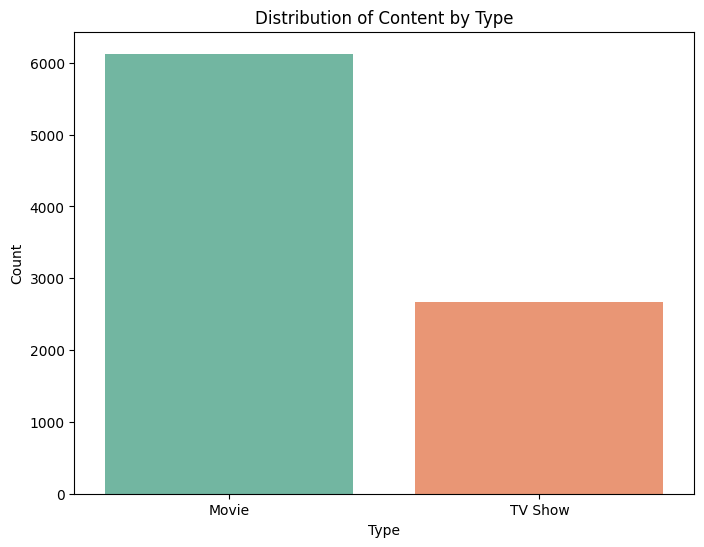

In [17]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=type_counts.index,
    y=type_counts.values,
    hue=type_counts.index,   
    palette='Set2',
    legend=False            
)

plt.title('Distribution of Content by Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()


In [18]:
# Split genres
data['genres'] = data['listed_in'].apply(lambda x: x.split(', '))

# Flatten the list
all_genres = sum(data['genres'], [])

# Count top 10 genres
genre_counts = pd.Series(all_genres).value_counts().head(10)

genre_counts


International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

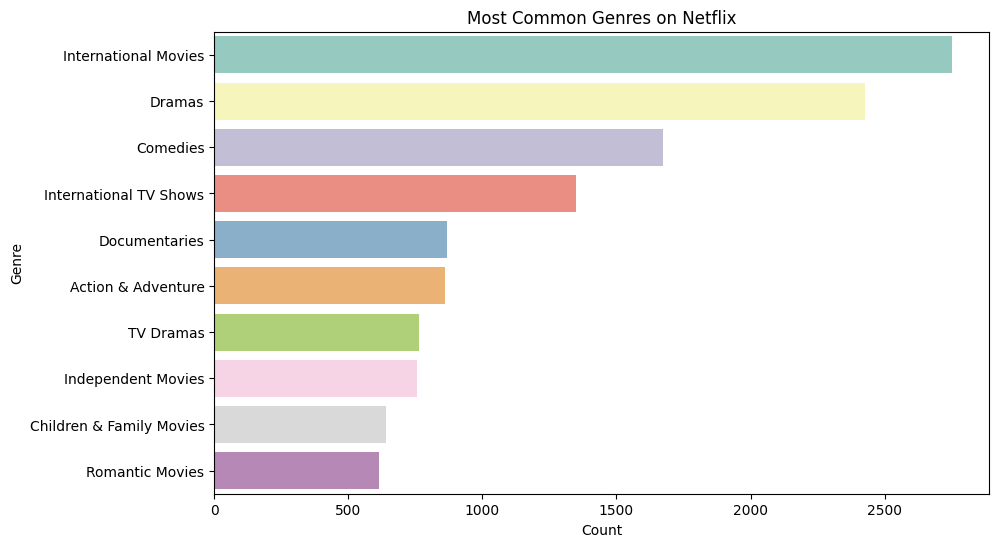

In [19]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index,
    hue=genre_counts.index,  
    palette='Set3',
    legend=False              
)
plt.title('Most Common Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()


In [20]:
data['year_added'] = data['date_added'].dt.year
data['month_added'] = data['date_added'].dt.month

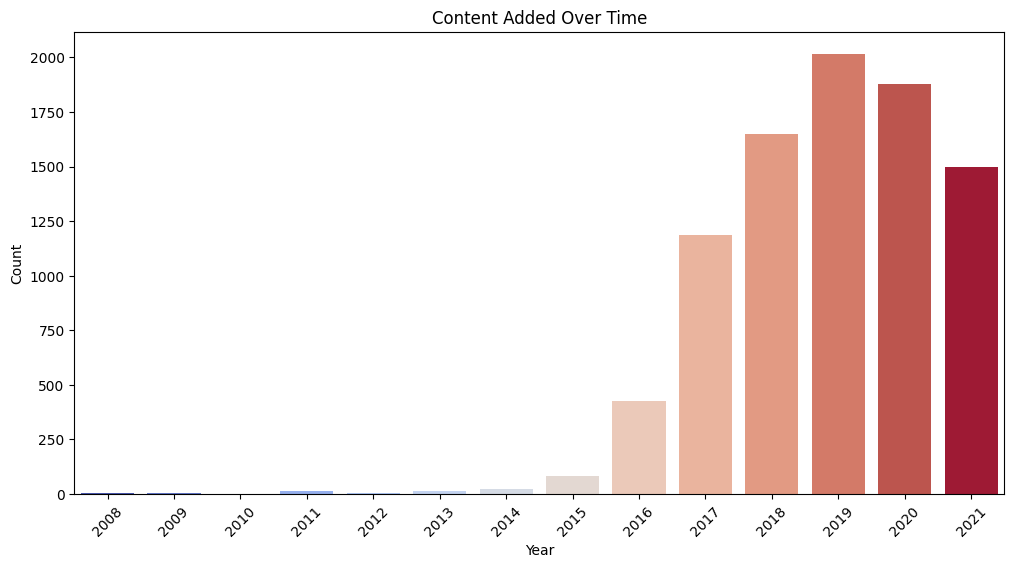

In [21]:
plt.figure(figsize=(12, 6))

sns.countplot(
    x='year_added',
    data=data,
    hue='year_added',     
    palette='coolwarm',
    legend=False          
)
plt.title('Content Added Over Time')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


In [22]:
top_directors = data['director'].value_counts().head(10)

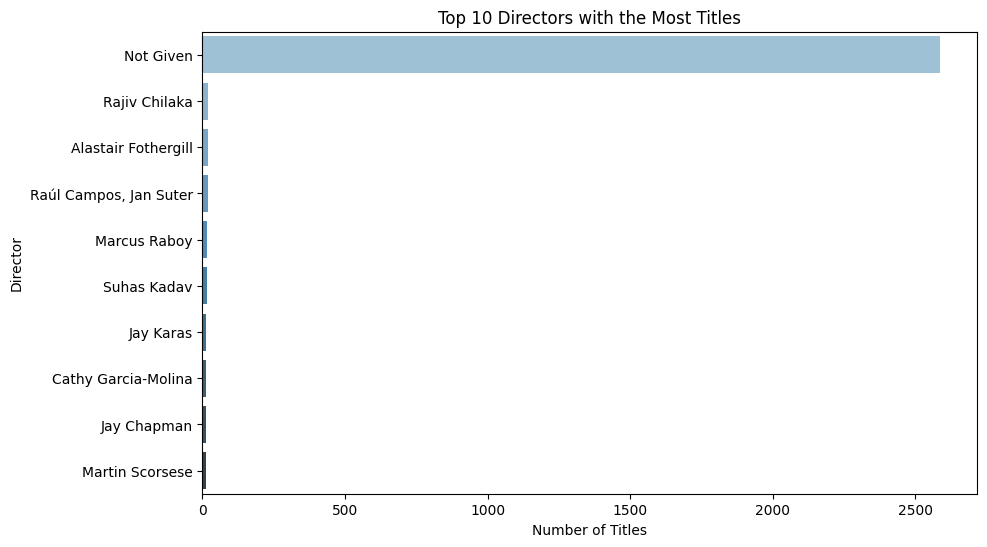

In [23]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index,
    hue=top_directors.index, 
    palette='Blues_d',
    legend=False               
)
plt.title('Top 10 Directors with the Most Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Director')
plt.show()


In [24]:
movie_titles = data[data['type'] == 'Movie']['title']
wordcloud = WordCloud(width=800, height=400,
background_color='black').generate(' '.join(movie_titles))

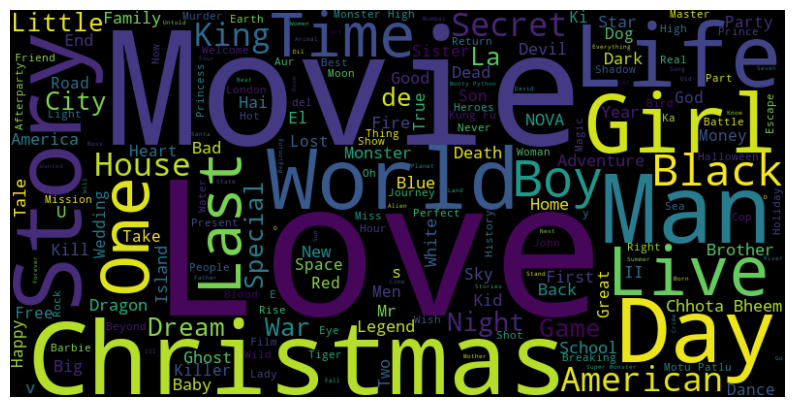

In [25]:
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

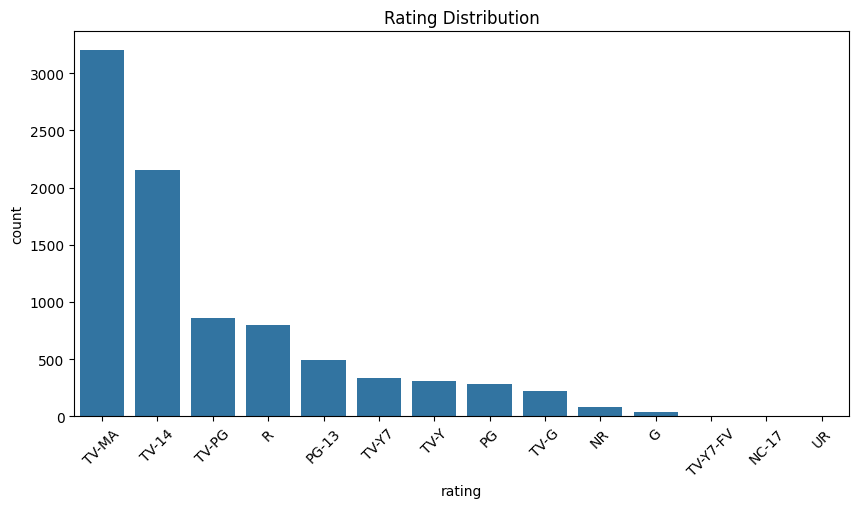

In [26]:
plt.figure(figsize=(10,5))
sns.countplot(x='rating', data=data, order=data['rating'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Rating Distribution')
plt.show()


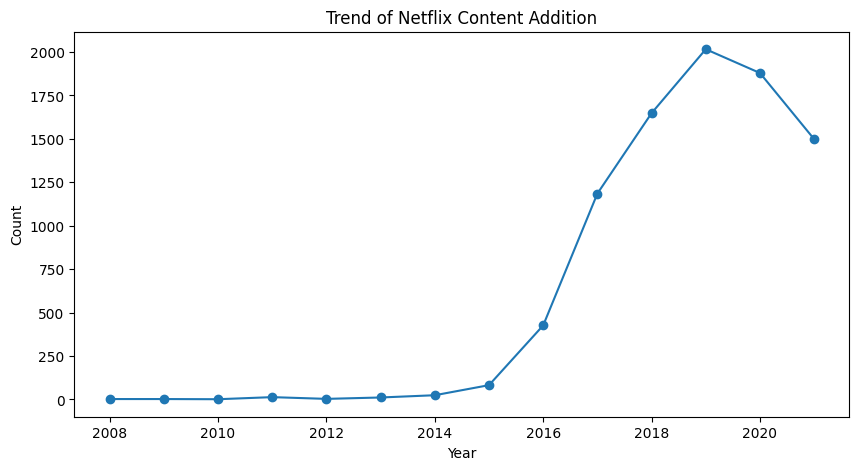

In [27]:
year_counts = data['year_added'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(year_counts.index, year_counts.values, marker='o')
plt.title('Trend of Netflix Content Addition')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()


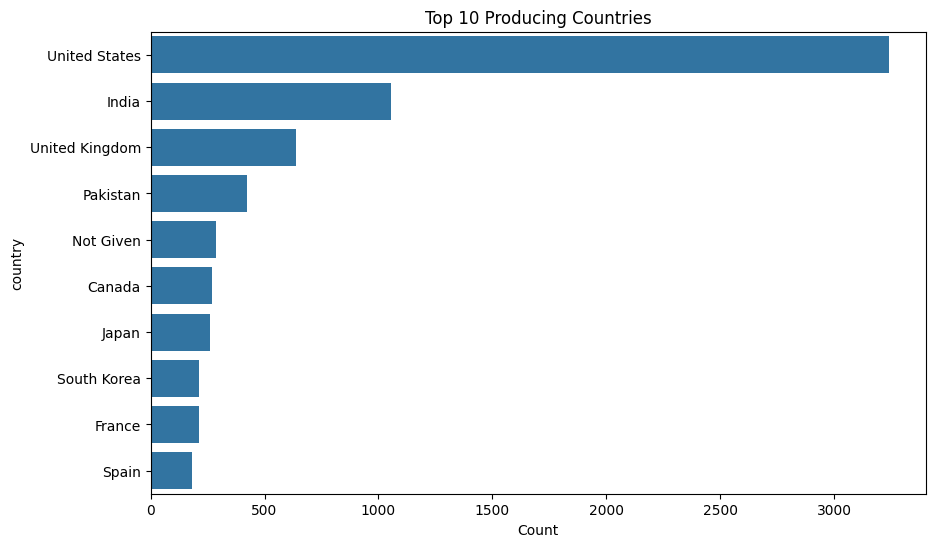

In [28]:

country_counts = (
    data['country']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(x=country_counts.values, y=country_counts.index)
plt.title('Top 10 Producing Countries')
plt.xlabel('Count')
plt.show()


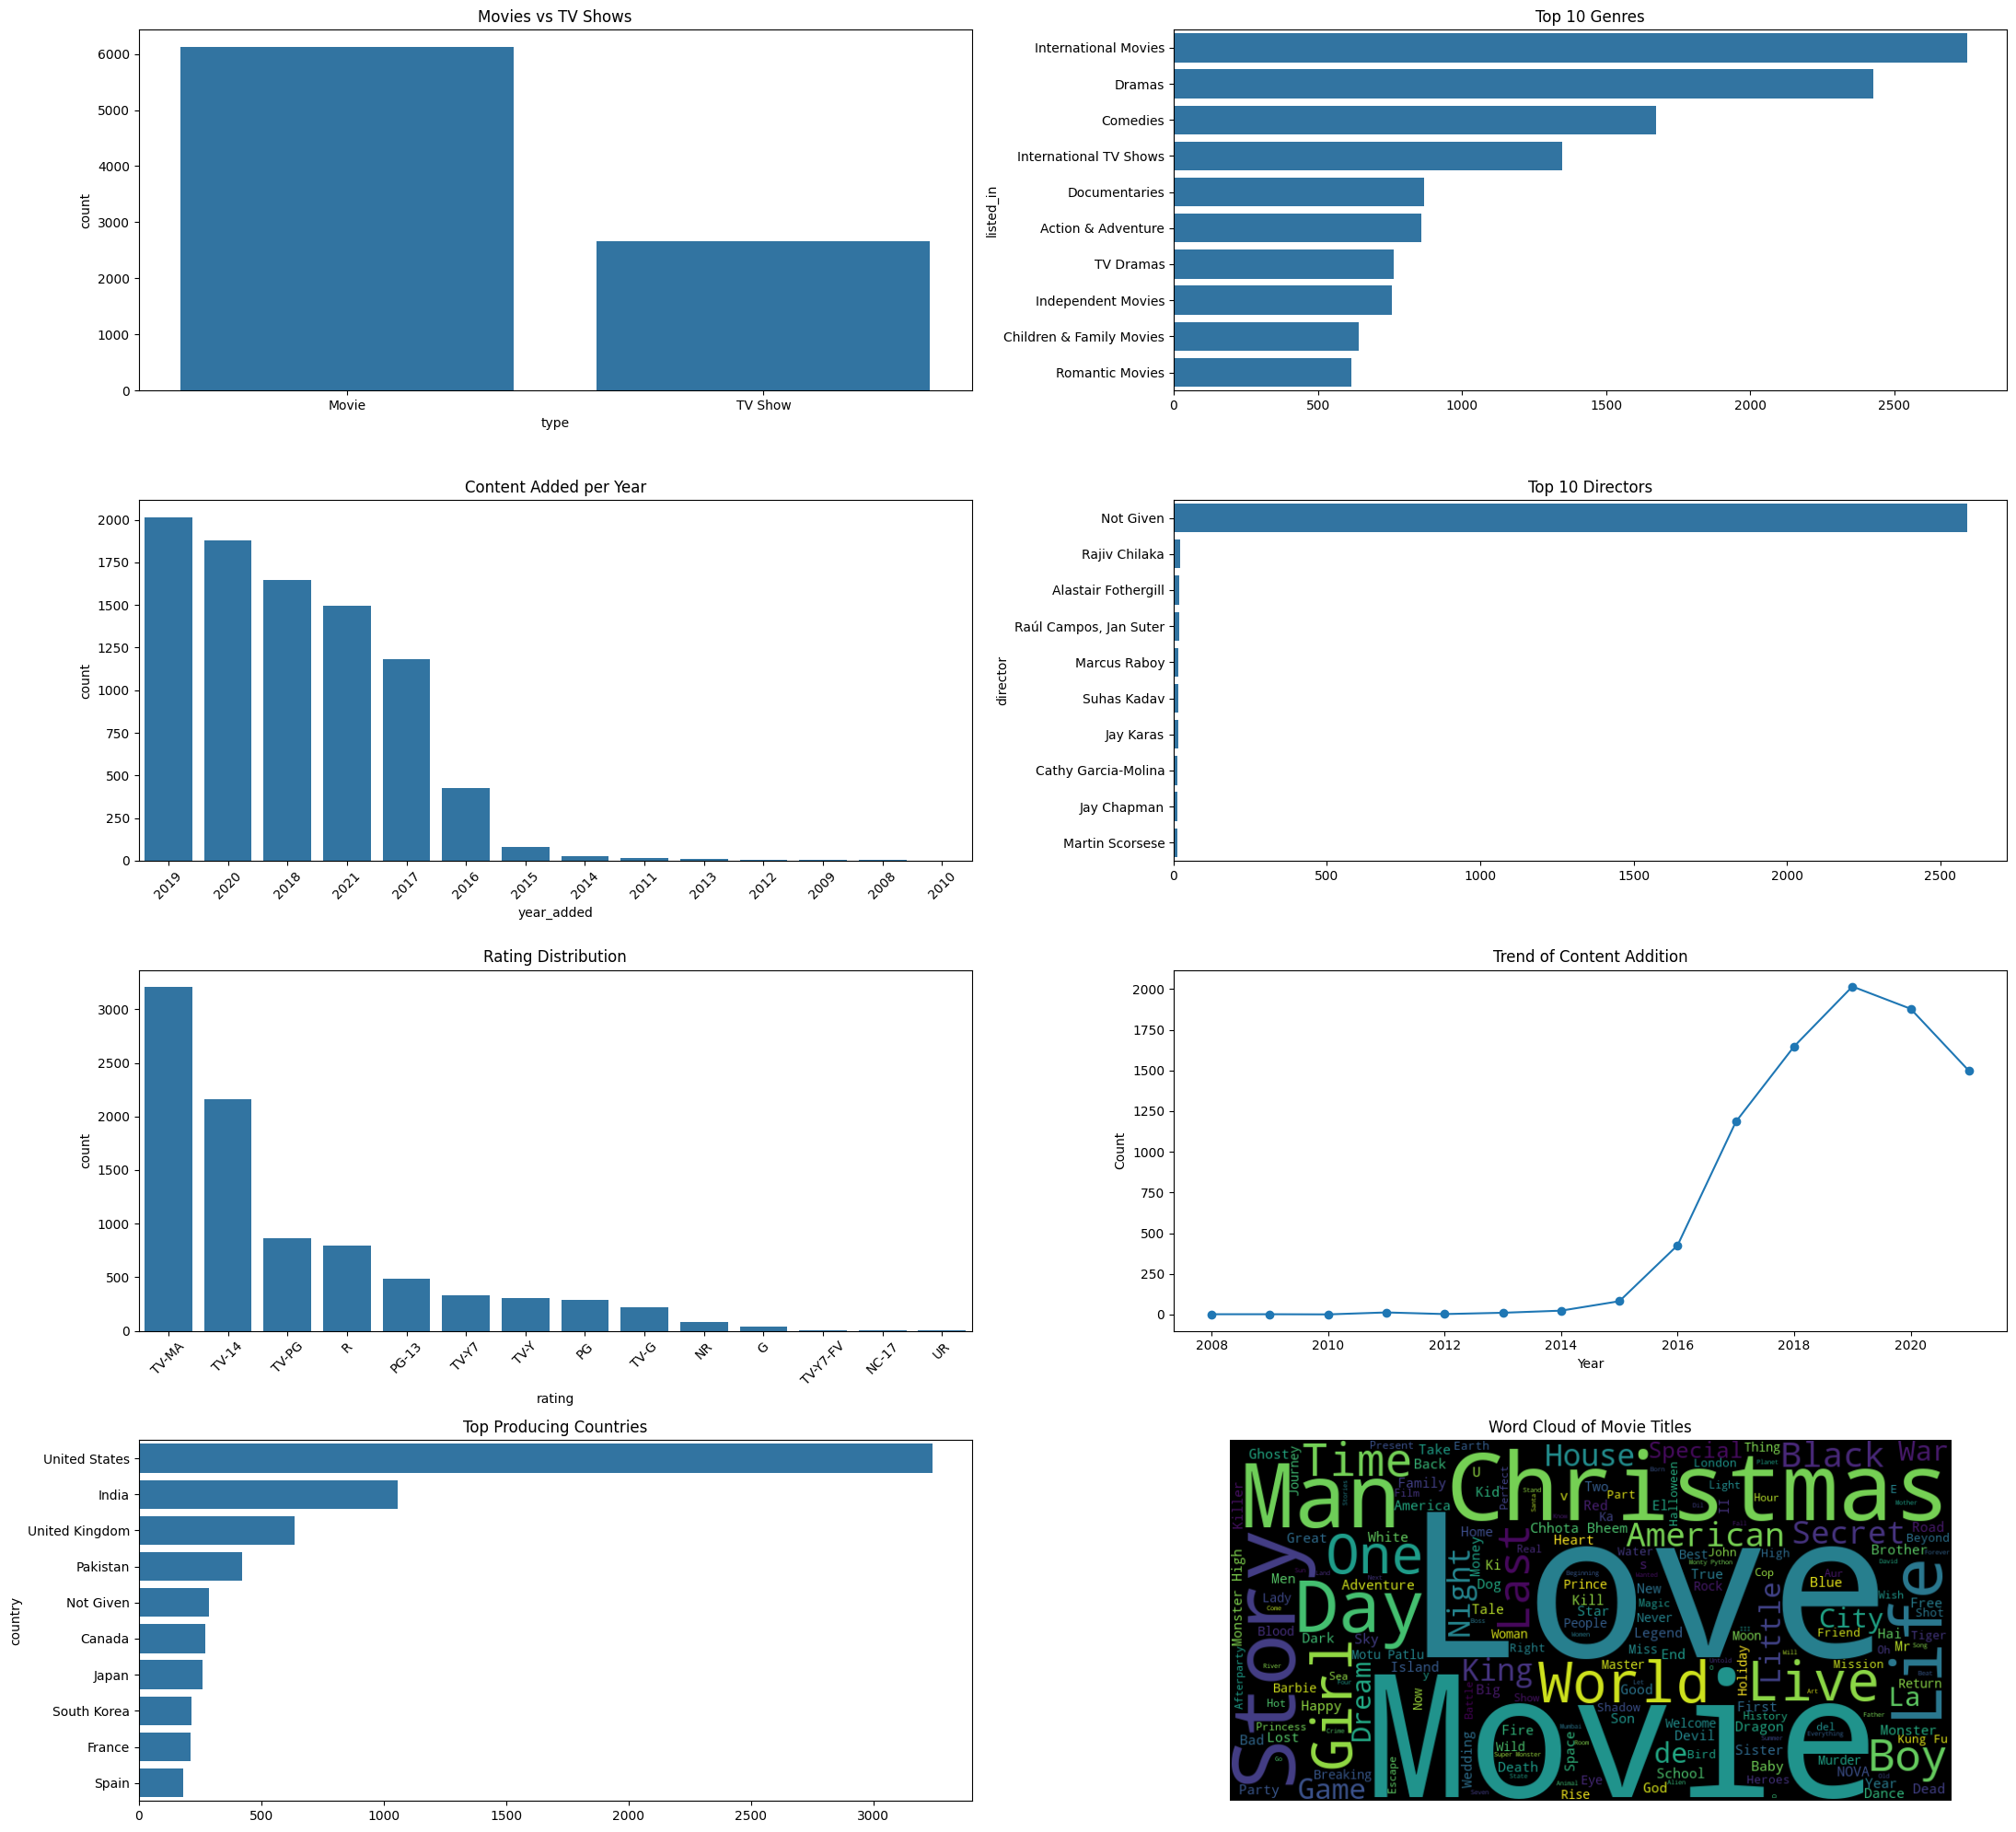

In [29]:

plt.figure(figsize=(22, 20))

# ---------------- 1. Movies vs TV Shows ----------------
plt.subplot(4, 2, 1)
sns.countplot(x='type', data=data)
plt.title('Movies vs TV Shows')

# ---------------- 2. Top Genres ----------------
genre_counts = (
    data['listed_in']
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

plt.subplot(4, 2, 2)
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title('Top 10 Genres')

# ---------------- 3. Content Added per Year ----------------
plt.subplot(4, 2, 3)
sns.countplot(x='year_added', data=data,
              order=data['year_added'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Content Added per Year')

# ---------------- 4. Top Directors ----------------
top_directors = data['director'].value_counts().head(10)

plt.subplot(4, 2, 4)
sns.barplot(x=top_directors.values, y=top_directors.index)
plt.title('Top 10 Directors')

# ---------------- 5. Rating Distribution ----------------
plt.subplot(4, 2, 5)
sns.countplot(x='rating', data=data,
              order=data['rating'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Rating Distribution')

# ---------------- 6. Year Trend Line ----------------
year_counts = data['year_added'].value_counts().sort_index()

plt.subplot(4, 2, 6)
plt.plot(year_counts.index, year_counts.values, marker='o')
plt.title('Trend of Content Addition')
plt.xlabel('Year')
plt.ylabel('Count')

# ---------------- 7. Top Countries ----------------
country_counts = (
    data['country']
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

plt.subplot(4, 2, 7)
sns.barplot(x=country_counts.values, y=country_counts.index)
plt.title('Top Producing Countries')

# ---------------- 8. Word Cloud ----------------
movie_titles = data[data['type'] == 'Movie']['title']
wordcloud = WordCloud(width=800, height=400,
                       background_color='black')\
                       .generate(' '.join(movie_titles))

plt.subplot(4, 2, 8)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Movie Titles')

# ---------------- Layout Adjustment ----------------
plt.tight_layout()
plt.show()


In [30]:
pip install dash plotly


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
!pip install plotly ipywidgets



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
!pip install anywidget



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
from IPython.display import display, clear_output

In [34]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"


In [35]:
data.columns

Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'genres',
       'year_added', 'month_added'],
      dtype='object')

In [36]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

types = ["All"] + sorted(data['type'].dropna().unique())
years = ["All"] + sorted(data['year_added'].dropna().unique())
ratings = ["All"] + sorted(data['rating'].dropna().unique())
countries = ["All"] + sorted(data['country'].dropna().unique())

fig = make_subplots(rows=2, cols=2,
                    subplot_titles=("Genres",
                                    "Ratings",
                                    "Growth",
                                    "Countries"))

# Default = All data
df = data.copy()

genres = df['listed_in'].dropna().str.split(', ').explode().value_counts().head(10)
ratings_c = df['rating'].value_counts().head(10)
years_c = df['year_added'].value_counts().sort_index()
countries_c = df['country'].dropna().str.split(', ').explode().value_counts().head(10)

fig.add_trace(go.Bar(x=genres.values, y=genres.index, orientation='h'),1,1)
fig.add_trace(go.Bar(x=ratings_c.index, y=ratings_c.values),1,2)
fig.add_trace(go.Scatter(x=years_c.index,y=years_c.values,mode='lines+markers'),2,1)
fig.add_trace(go.Bar(x=countries_c.values,y=countries_c.index,orientation='h'),2,2)

# -------- FILTER BUTTON GENERATOR --------
def make_buttons(column, options):
    buttons = []
    for val in options:
        df_f = data if val == "All" else data[data[column] == val]

        genres = df_f['listed_in'].dropna().str.split(', ').explode().value_counts().head(10)
        ratings_c = df_f['rating'].value_counts().head(10)
        years_c = df_f['year_added'].value_counts().sort_index()
        countries_c = df_f['country'].dropna().str.split(', ').explode().value_counts().head(10)

        buttons.append(dict(
            label=str(val),
            method="update",
            args=[{
                "x": [genres.values,
                      ratings_c.index,
                      years_c.index,
                      countries_c.values],
                "y": [genres.index,
                      ratings_c.values,
                      years_c.values,
                      countries_c.index]
            }]
        ))
    return buttons

# -------- DROPDOWN MENUS --------
fig.update_layout(
    template="plotly_dark",
    height=800,
    width=1300,
    title="Netflix Dashboard",
    showlegend=False,

    updatemenus=[
        dict(buttons=make_buttons("type", types),
             x=0.55, y=1.18, xanchor="left"),
        
        dict(buttons=make_buttons("year_added", years),
             x=0.70, y=1.18, xanchor="left"),
        
        dict(buttons=make_buttons("rating", ratings),
             x=0.85, y=1.18, xanchor="left"),
        
        dict(buttons=make_buttons("country", countries),
             x=1.00, y=1.18, xanchor="left"),
    ]
)

fig.show()
